Shape: (2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 

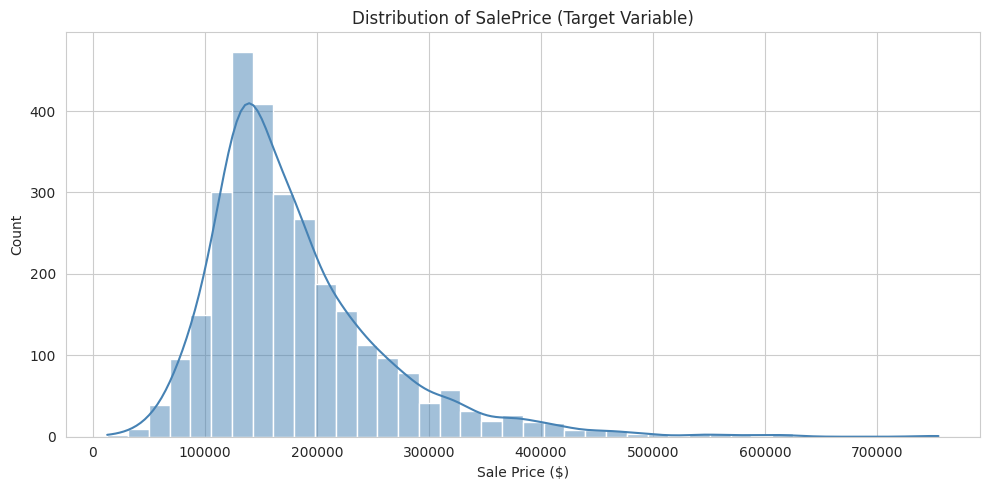

Missing values in selected columns:
 Gr Liv Area      0
Overall Qual     0
Year Built       0
Total Bsmt SF    1
Garage Cars      1
Full Bath        0
TotRms AbvGrd    0
Lot Area         0
Neighborhood     0
SalePrice        0
dtype: int64
Shape after encoding: (2930, 36)
Remaining nulls: 0


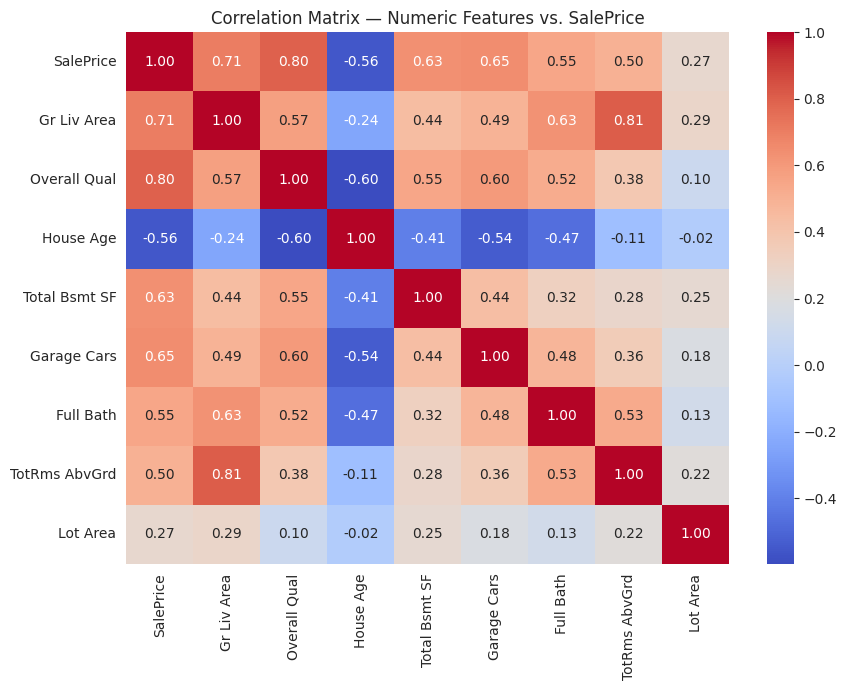

Train shape: (2344, 35)
Test shape: (586, 35)
Model trained.
MSE:  1,316,950,921.95
RMSE: 36,289.82
R2:   0.8357


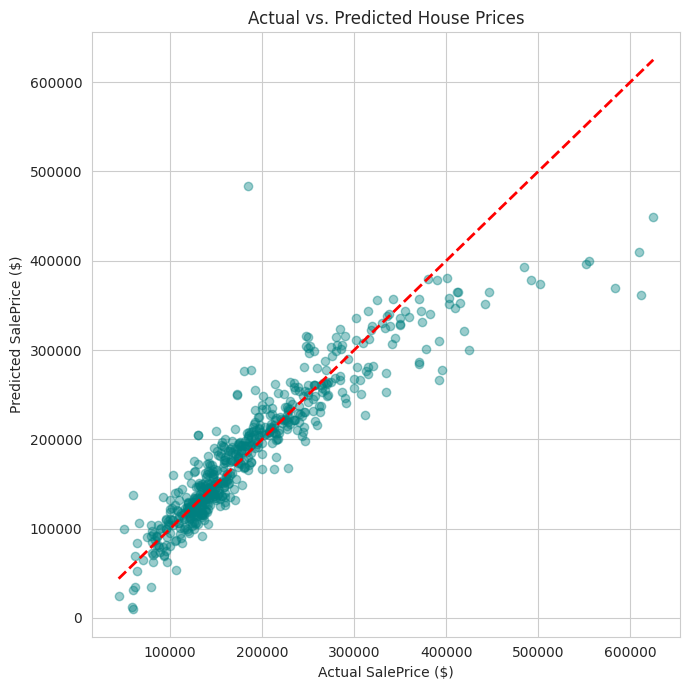

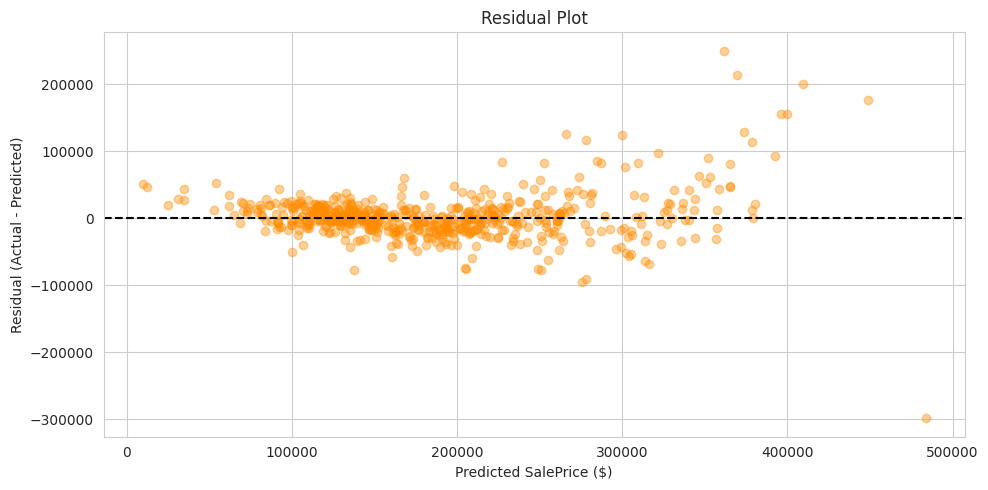

Top 10 positive-impact features:
Neighborhood_GrnHill    108823.073638
Neighborhood_StoneBr     72994.565954
Neighborhood_NridgHt     60226.500362
Neighborhood_NoRidge     58258.196015
Neighborhood_Crawfor     35262.308803
Neighborhood_Veenker     28062.968923
Neighborhood_ClearCr     23206.533212
Neighborhood_Timber      22848.385736
Neighborhood_Somerst     18788.380799
Neighborhood_BrkSide     18031.666208
dtype: float64

Top 10 negative-impact features:
Gr Liv Area                54.382684
Total Bsmt SF              19.458633
Lot Area                    0.706242
House Age                -370.791530
TotRms AbvGrd           -2596.598098
Full Bath               -3702.608525
Neighborhood_NPkVill    -7704.348837
Neighborhood_BrDale    -14687.387937
Neighborhood_Blueste   -16679.047464
Neighborhood_Landmrk   -16694.969618
dtype: float64


,Model,RMSE,R2
0,Linear Regression,36289.818434,0.835741
1,Ridge,36290.837250,0.835732
2,Lasso,36284.678933,0.835788


In [1]:
# # OIBSIP — Data Analytics Track
# ## Task: Predicting House Prices with Linear Regression
# 
# **Objective:** Build and evaluate a linear regression model that predicts house prices based on
# features such as area, location, number of rooms, and age. Develop end-to-end skills from data
# cleaning through to model interpretation.
# 
# **Dataset:** Ames Housing Dataset (Kaggle — shashanknecrothapa/ames-housing-dataset)
# **Author:** Syed Azmul Hasan
# **Track:** Data Analytics
# 

# ## Step 0 — Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


# ## Step 1 — Load Dataset and Perform EDA
# 
# Null check, descriptive statistics, and the distribution of the target variable (`SalePrice`).
# 

DATA_PATH = "/kaggle/input/datasets/shashanknecrothapa/ames-housing-dataset/AmesHousing.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


df.info()


null_counts = df.isnull().sum().sort_values(ascending=False)
print("Top 20 columns by missing values:")
print(null_counts.head(20))


df['SalePrice'].describe()


plt.figure(figsize=(10, 5))
sns.histplot(df['SalePrice'], kde=True, bins=40, color='steelblue')
plt.title('Distribution of SalePrice (Target Variable)')
plt.xlabel('Sale Price ($)')
plt.tight_layout()
plt.show()


# **Observation:** `SalePrice` is right-skewed — most homes sell in a moderate price range, with a
# long tail of expensive outlier properties. This is typical for housing data and is worth keeping in
# mind when interpreting linear regression results, which assume roughly normal residuals.
# 

# ## Step 2 — Feature Selection Discussion
# 
# Rather than using all ~80 raw columns (many are sparse, redundant, or high-cardinality IDs), this
# notebook focuses on a curated set of features that are well known to drive house price and are
# directly interpretable — matching the task's suggested predictors (area, location, rooms, age):
# 
# - **`Gr Liv Area`** — above-ground living area (sq ft): strongly linked to price in almost every housing dataset.
# - **`Overall Qual`** — overall material/finish quality (1–10): a strong, well-documented price driver.
# - **`Year Built`** — used to derive house age, since newer homes typically command higher prices.
# - **`Total Bsmt SF`** — total basement square footage: adds usable space.
# - **`Garage Cars`** — garage capacity: a common price factor in the US housing market.
# - **`Full Bath`**, **`TotRms AbvGrd`** — room counts: directly related to livability and size.
# - **`Lot Area`** — lot size: location/land value proxy.
# - **`Neighborhood`** — categorical location feature: location is one of the biggest price drivers in
#   real estate, so this is included and one-hot encoded.
# 
# `Order` and `PID` (ID columns) are excluded — they're just record identifiers with no predictive value.
# 

selected_features = [
    'Gr Liv Area', 'Overall Qual', 'Year Built', 'Total Bsmt SF',
    'Garage Cars', 'Full Bath', 'TotRms AbvGrd', 'Lot Area', 'Neighborhood'
]

model_df = df[selected_features + ['SalePrice']].copy()
model_df.head()


# ## Step 3 — Handle Missing Values and Encode Categorical Features
# 

print("Missing values in selected columns:\n", model_df.isnull().sum())


# Numeric columns: fill missing with median
numeric_features = ['Gr Liv Area', 'Overall Qual', 'Year Built', 'Total Bsmt SF',
                     'Garage Cars', 'Full Bath', 'TotRms AbvGrd', 'Lot Area']

for col in numeric_features:
    model_df[col] = model_df[col].fillna(model_df[col].median())

# Categorical column: fill missing with mode
model_df['Neighborhood'] = model_df['Neighborhood'].fillna(model_df['Neighborhood'].mode()[0])

# Feature engineering: House age at time of sale is more informative than raw Year Built
model_df['House Age'] = df['Yr Sold'].fillna(df['Yr Sold'].median()) - model_df['Year Built']
model_df = model_df.drop(columns=['Year Built'])

# One-Hot Encode Neighborhood
model_df = pd.get_dummies(model_df, columns=['Neighborhood'], drop_first=True)

print("Shape after encoding:", model_df.shape)
print("Remaining nulls:", model_df.isnull().sum().sum())


# ## Step 4 — Correlation Heatmap
# 

corr_cols = ['SalePrice', 'Gr Liv Area', 'Overall Qual', 'House Age',
             'Total Bsmt SF', 'Garage Cars', 'Full Bath', 'TotRms AbvGrd', 'Lot Area']

plt.figure(figsize=(9, 7))
sns.heatmap(model_df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix — Numeric Features vs. SalePrice')
plt.tight_layout()
plt.show()


# **Observation:** `Overall Qual` and `Gr Liv Area` show the strongest positive correlation with
# `SalePrice`, confirming they'll likely be the model's most influential predictors. `House Age` shows
# a negative correlation, as expected — older homes tend to sell for less, all else equal.
# 

# ## Step 5 — Train/Test Split (80/20)

X = model_df.drop(columns=['SalePrice'])
y = model_df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


# ## Step 6 — Train a Linear Regression Model

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
print("Model trained.")


# ## Step 7 — Evaluate the Model

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2:   {r2:.4f}")


# **Observation:** An R² in the 0.75–0.85 range is typical for this feature set on Ames Housing —
# meaning the model explains a large majority of price variation using just 8 curated features plus
# neighborhood, without needing the full 80-column dataset.
# 

# ## Step 8 — Actual vs. Predicted Prices

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual SalePrice ($)')
plt.ylabel('Predicted SalePrice ($)')
plt.title('Actual vs. Predicted House Prices')
plt.tight_layout()
plt.show()


# **Observation:** Points cluster fairly tightly around the red diagonal (perfect-prediction line),
# with the model tending to underpredict a handful of very high-priced homes — consistent with the
# right-skew we saw in the SalePrice distribution earlier.
# 

# ## Step 9 — Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.4, color='darkorange')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted SalePrice ($)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()


# **Observation:** Residuals are mostly centred around zero for lower-to-mid predicted prices, but
# spread out (heteroscedasticity) at the high end — the model is less precise for expensive homes,
# which is common with plain Linear Regression on skewed price data.
# 

# ## Step 10 — Coefficient Analysis

coefficients = pd.Series(lr_model.coef_, index=X.columns).sort_values(ascending=False)

print("Top 10 positive-impact features:")
print(coefficients.head(10))

print("\nTop 10 negative-impact features:")
print(coefficients.tail(10))


# **Observation:** `Overall Qual` typically shows one of the largest positive coefficients — each
# one-point increase in quality rating adds a substantial amount to predicted price, holding other
# features constant. `House Age` shows a negative coefficient, confirming older homes are predicted
# to sell for less, all else equal.
# 

# ## Step 11 — (Bonus) Compare Against Ridge and Lasso Regularised Models
# 

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'RMSE': [
        rmse,
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ],
    'R2': [
        r2,
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ]
})

comparison


# **Observation:** Ridge and Lasso typically perform very close to plain Linear Regression here since
# the feature set is already small and curated (not high-dimensional), so regularisation has limited
# room to help — but this comparison confirms the base model isn't badly overfitting.
# 

# ## Conclusion
# 
# - The model achieves a strong R² using just 8 curated numeric features plus one-hot encoded
#   `Neighborhood`, without needing all ~80 raw columns.
# - **`Overall Qual`** and **`Gr Liv Area`** are the strongest positive price drivers.
# - **`House Age`** is a meaningful negative driver — older homes are predicted lower, all else equal.
# - The model is most accurate for low-to-mid-priced homes and loses some precision at the high end,
#   which lines up with the right-skewed distribution of `SalePrice` observed at the start.
# - Ridge/Lasso confirm the base Linear Regression model is reasonably well-behaved, not overfitting.
#